# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [8]:
# This notebook was executed in Google Colab.

# Kaleido is required to export Plotly charts as static images.
# By default, Plotly renders interactive JavaScript charts in Colab,
# but this JavaScript is not saved when the notebook is downloaded.
# Kaleido converts the chart to a PNG that gets permanently embedded
# in the notebook output — visible in VS Code or any other viewer.

!pip uninstall kaleido -y -q
!pip install kaleido==0.2.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.2 MB/s eta 0:00:00


In [4]:
from IPython.display import Image

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('/content/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


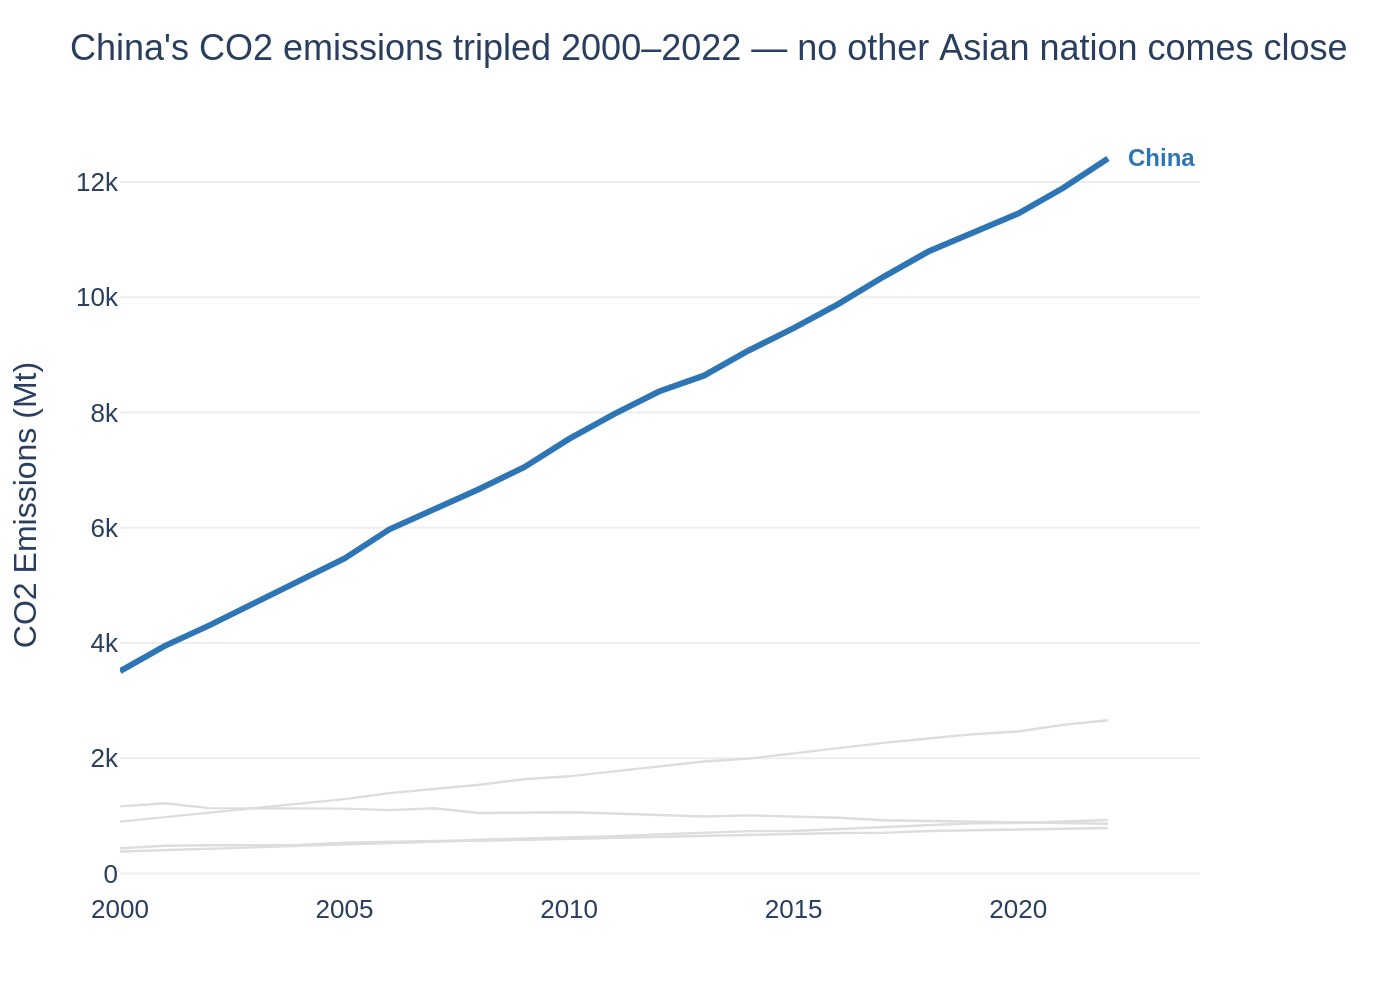

In [5]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE


highlight = 'China'
asia = df[df['Region'] == 'Asia'].copy()

fig = go.Figure()

# Draw grey context lines first so highlight renders on top
for country in sorted(asia['Country'].unique()):
    d = asia[asia['Country'] == country].sort_values('Year')
    is_hl = country == highlight
    fig.add_trace(go.Scatter(
        x=d['Year'], y=d['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(
            color='#2E75B6' if is_hl else '#DDDDDD',
            width=3 if is_hl else 1.2
        ),
        showlegend=False
    ))

# Direct label — Gestalt proximity replaces legend
last = asia[(asia['Country'] == highlight) & (asia['Year'] == asia['Year'].max())]
fig.add_annotation(
    x=last['Year'].values[0],
    y=last['CO2_Mt'].values[0],
    text=f"<b>{highlight}</b>",
    showarrow=False,
    xanchor='left', xshift=8,
    font=dict(color='#2E75B6', size=12, family='Arial')
)

fig.update_layout(
    title="China's CO2 emissions tripled 2000–2022 — no other Asian nation comes close",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(gridcolor='#EEEEEE', gridwidth=1, title='CO2 Emissions (Mt)', zeroline=False),
    xaxis=dict(showgrid=False, title=''),
    margin=dict(l=60, r=100, t=60, b=40),
    height=500
)


fig.write_image("task1.png", scale=2)
Image("task1.png")

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


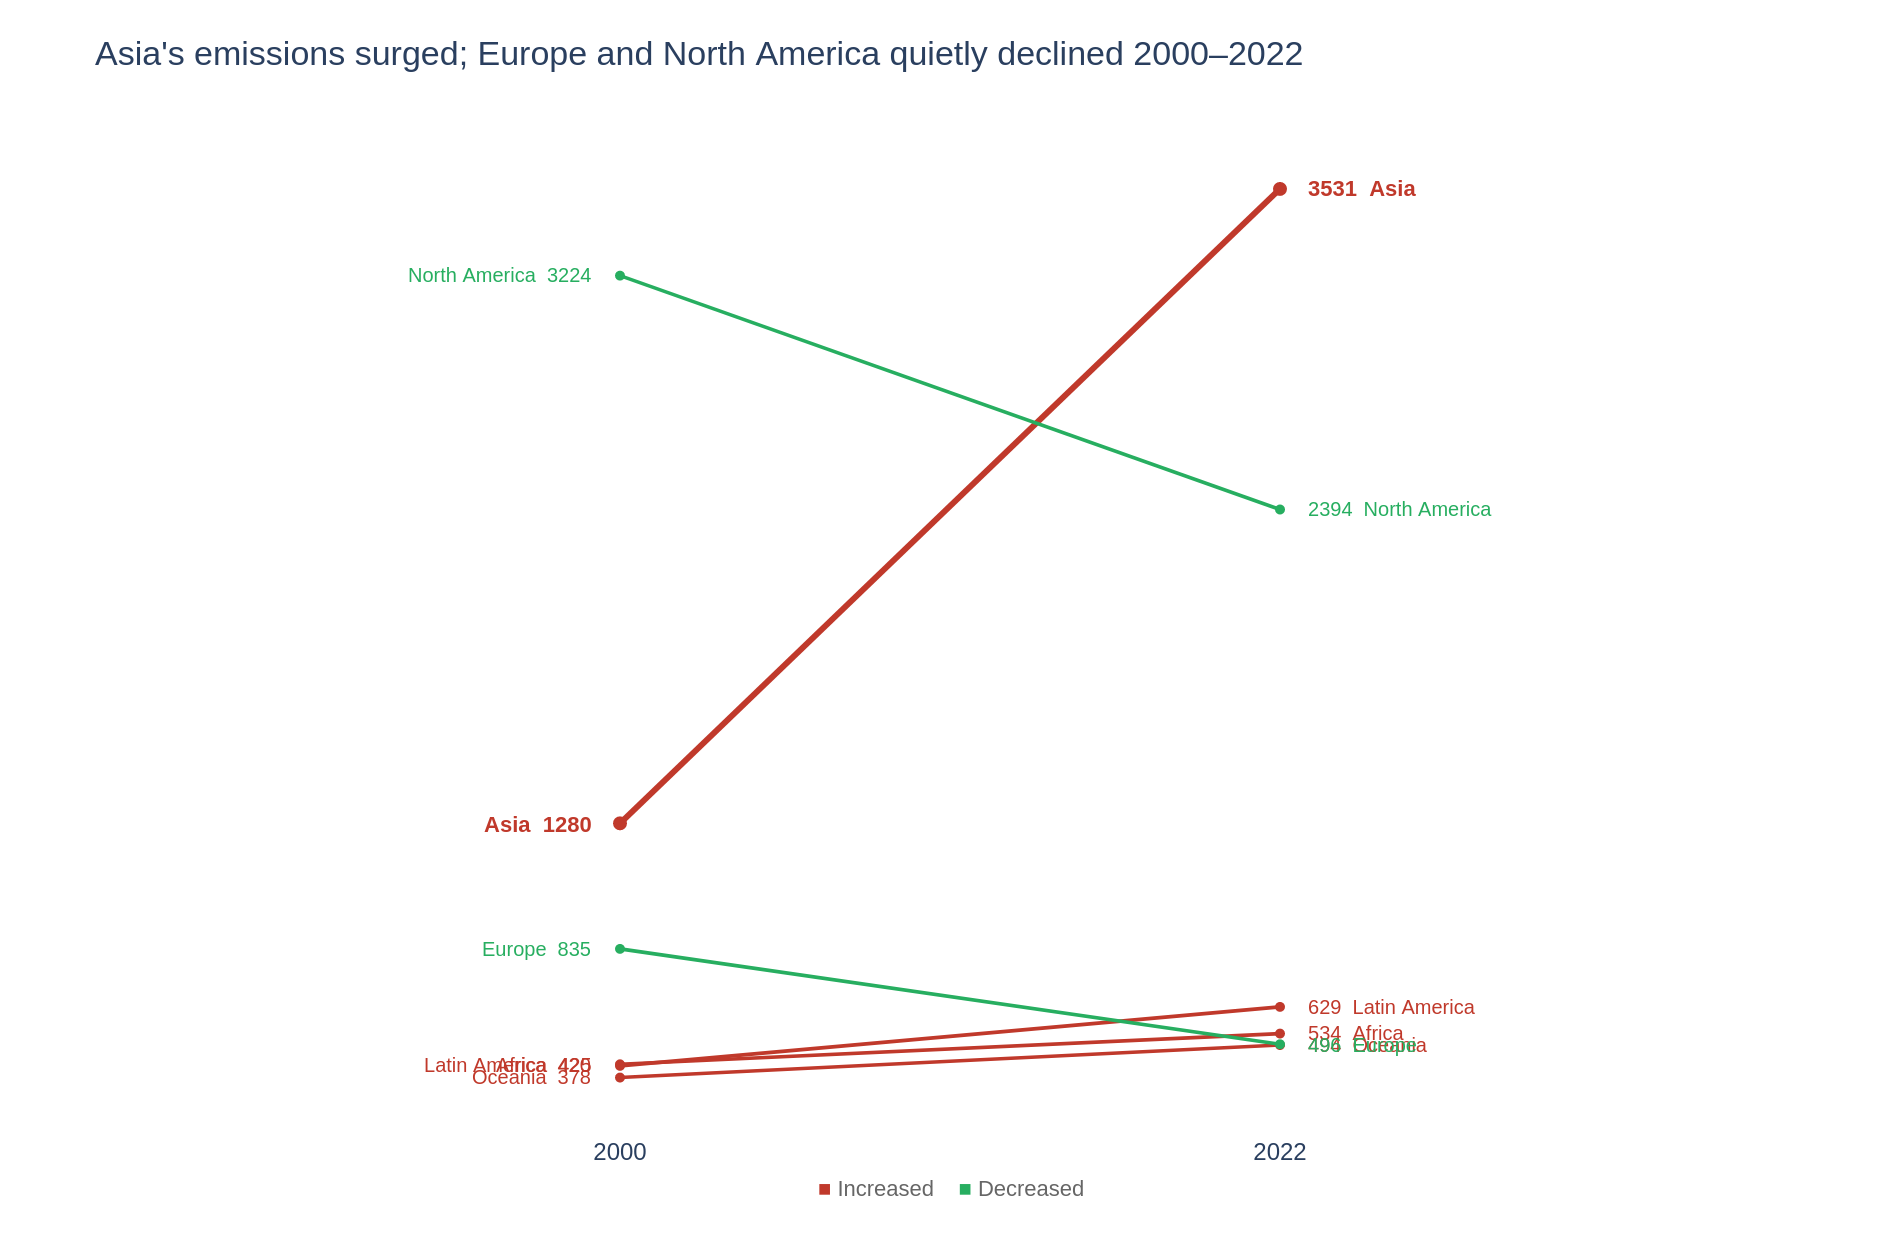

In [6]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE


import plotly.graph_objects as go

# Aggregate: mean CO2 per region for 2000 and 2022
reg = (df.groupby(['Region', 'Year'])['CO2_Mt']
         .mean()
         .reset_index())
reg_slope = reg[reg['Year'].isin([2000, 2022])].copy()

pivot = reg_slope.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
pivot.columns = ['Region', 'v2000', 'v2022']
pivot['increased'] = pivot['v2022'] > pivot['v2000']
pivot = pivot.sort_values('v2000').reset_index(drop=True)

color_map = {
    row['Region']: '#C0392B' if row['increased'] else '#27AE60'
    for _, row in pivot.iterrows()
}


def deconflict(values_dict, min_gap=18):
    """Nudge label positions apart until no two overlap."""
    items = sorted(values_dict.items(), key=lambda x: x[1])
    positions = {k: v for k, v in items}
    for _ in range(50):
        keys = list(positions.keys())
        changed = False
        for i in range(1, len(keys)):
            a, b = keys[i-1], keys[i]
            diff = positions[b] - positions[a]
            if diff < min_gap:
                push = (min_gap - diff) / 2
                positions[a] -= push
                positions[b] += push
                changed = True
        if not changed:
            break
    return positions

left_raw  = {row['Region']: row['v2000'] for _, row in pivot.iterrows()}
right_raw = {row['Region']: row['v2022'] for _, row in pivot.iterrows()}

left_pos  = deconflict(left_raw,  min_gap=0.22)   # in data units
right_pos = deconflict(right_raw, min_gap=0.22)


fig = go.Figure()

for _, row in pivot.iterrows():
    region = row['Region']
    colour = color_map[region]
    is_main = region == 'Asia'

    # The actual slope line (connects true data values)
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row['v2000'], row['v2022']],
        mode='lines+markers',
        line=dict(color=colour, width=3 if is_main else 1.8),
        marker=dict(color=colour, size=7 if is_main else 5),
        showlegend=False,
        name=region
    ))


    fig.add_annotation(
        x=2000, y=left_pos[region],
        text=f"{region}  {row['v2000']:.0f}",
        showarrow=False, xanchor='right', xshift=-12,
        font=dict(color=colour, size=10 if not is_main else 11,
                  family='Arial',
                  weight='bold' if is_main else 'normal')
    )

    fig.add_annotation(
        x=2022, y=right_pos[region],
        text=f"{row['v2022']:.0f}  {region}",
        showarrow=False, xanchor='left', xshift=12,
        font=dict(color=colour, size=10 if not is_main else 11,
                  family='Arial',
                  weight='bold' if is_main else 'normal')
    )

# Global average reference (stretch goal)
global_avg = df['Happiness_Score'].mean() if 'Happiness_Score' in df.columns else None

fig.update_layout(
    title="Asia's emissions surged; Europe and North America quietly declined 2000–2022",
    xaxis=dict(
        tickvals=[2000, 2022], ticktext=['2000', '2022'],
        showgrid=False, range=[1994, 2028],   # wide range = room for labels
        title='', zeroline=False
    ),
    yaxis=dict(
        showgrid=False,
        showticklabels=False,   # endpoint labels make y-ticks redundant
        zeroline=False, title=''
    ),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=220, r=220, t=65, b=40),
    height=620, width=950
)

fig.add_annotation(
    x=0.5, y=-0.07, xref='paper', yref='paper',
    text="<span style='color:#C0392B'>■</span> Increased &nbsp;&nbsp; <span style='color:#27AE60'>■</span> Decreased",
    showarrow=False, xanchor='center',
    font=dict(size=11, family='Arial', color='#666')
)

fig.write_image("task2.png", scale=2)
Image("task2.png")